# Model Evaluation

## Objective

Evaluate machine learning models using multiple metrics and visualizations to select the most appropriate fraud detection model.

### Evaluation Metrics

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Precision-Recall Curve
- Confusion Matrix

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc
)

import joblib
from pathlib import Path

In [2]:
df = pd.read_csv("../data/processed/cleaned_creditcard.csv")

In [3]:
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [4]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

In [5]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    probabilities = model.predict_proba(X_test)[:,1]

    results.append({

        "Model": name,

        "Accuracy": accuracy_score(y_test,predictions),

        "Precision": precision_score(y_test,predictions),

        "Recall": recall_score(y_test,predictions),

        "F1": f1_score(y_test,predictions),

        "ROC AUC": roc_auc_score(
            y_test,
            probabilities
        )

    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    by="F1",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC AUC
3,Extra Trees,0.999559,0.986111,0.747368,0.850299,0.929633
2,Random Forest,0.999507,0.971831,0.726316,0.831325,0.923949
4,Gradient Boosting,0.999242,0.861111,0.652632,0.742515,0.853926
1,Decision Tree,0.999048,0.720430,0.705263,0.712766,0.852402
0,Logistic Regression,0.999119,0.846154,0.578947,0.687500,0.956047


In [6]:
import plotly.express as px

fig = px.bar(

    results_df,

    x="Model",

    y="F1",

    color="Model",

    title="Model Comparison using F1 Score"

)

fig.show()

In [7]:
best_model_name = results_df.sort_values(
    by="F1",
    ascending=False
).iloc[0]["Model"]

best_model = models[best_model_name]

predictions = best_model.predict(X_test)

<Axes: >

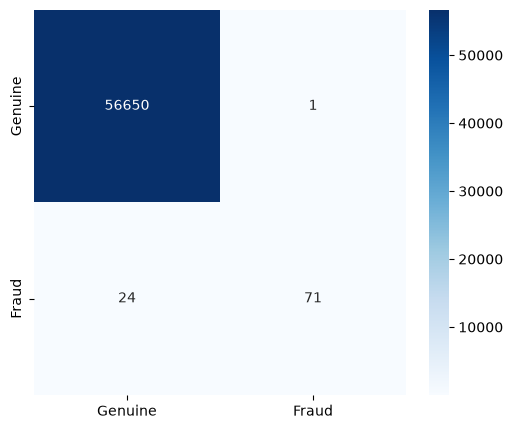

In [15]:
cm = confusion_matrix(y_test,predictions)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Genuine", "Fraud"],
    yticklabels=["Genuine", "Fraud"]
)

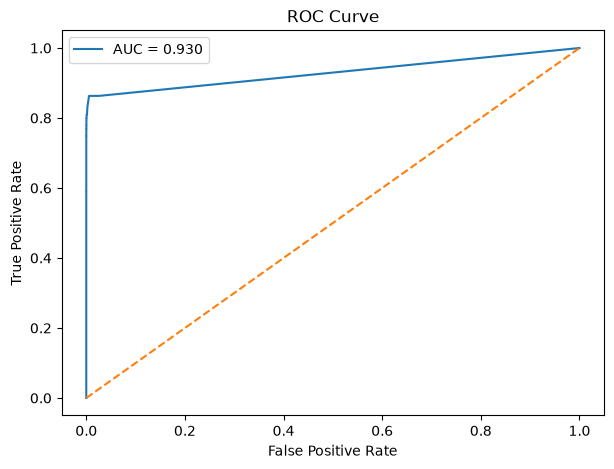

In [9]:
probabilities = best_model.predict_proba(X_test)[:,1]

fpr,tpr,_ = roc_curve(
    y_test,
    probabilities
)

plt.figure(figsize=(7,5))

plt.plot(

    fpr,

    tpr,

    label=f"AUC = {roc_auc_score(y_test, probabilities):.3f}"

)

plt.plot([0,1],[0,1],"--")

plt.legend()

plt.title("ROC Curve")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.show()

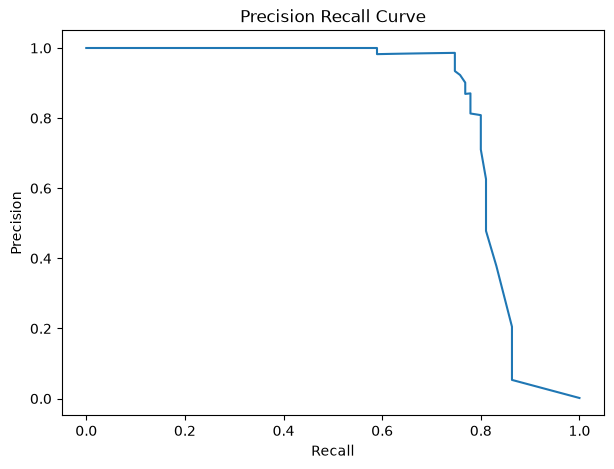

In [10]:
precision,recall,_ = precision_recall_curve(
    y_test,
    probabilities
)

plt.figure(figsize=(7,5))

plt.plot(

    recall,

    precision

)

plt.title("Precision Recall Curve")

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.show()

In [11]:
if hasattr(best_model,"feature_importances_"):

    importance = pd.DataFrame({

        "Feature": X.columns,

        "Importance": best_model.feature_importances_

    })

    importance = importance.sort_values(
        by="Importance",
        ascending=False
    )

    importance.head(15)

In [12]:
fig = px.bar(

    importance.head(15),

    x="Importance",

    y="Feature",

    orientation="h",

    title="Top Feature Importances"

)

fig.show()

In [13]:
print(

    classification_report(

        y_test,

        predictions

    )

)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.99      0.75      0.85        95

    accuracy                           1.00     56746
   macro avg       0.99      0.87      0.93     56746
weighted avg       1.00      1.00      1.00     56746



In [16]:
results_df.to_csv(
    "../reports/model_comparison.csv",
    index=False
)

# Business Interpretation

## Key Findings

- The selected model achieved the highest F1 Score.
- ROC-AUC indicates strong discrimination between fraudulent and genuine transactions.
- High recall is particularly important because missing fraudulent transactions has a direct financial impact.
- Precision should also remain high to reduce unnecessary fraud investigations.

## Recommendation

Deploy the selected model for real-time fraud detection while continuously monitoring performance on new data.

In [14]:
Path("../models").mkdir(exist_ok=True)

joblib.dump(

    best_model,

    "../models/fraud_detection_model.pkl"

)

['../models/fraud_detection_model.pkl']